Here we are going to use our Data to Develope a Model that will take input an Image and Predict it's class.

In [802]:
# Imports
import numpy as np
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt
import random
from tensorflow import keras
from tensorflow.keras import layers

In [803]:
# Makes Tensorflow showing less erros messages.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [804]:
print(tf.__version__)

2.6.0


## Importing Images

In [805]:
# Lists all the file names from the Source folder
base_path = 'data/train/training_data_resized/'

files = os.listdir(base_path)
files = [file for file in files if file[-1] != '~']

print(len(files))

48


In [806]:
# Getting all the images in RGB formats and storing them all in a container array
classes = ['Alpha', 'Beta', 'Gamma']

X = []
y = []

for file in files:
    # Creating the File path (Image Path).
    file_path = base_path + file
    # Opening the Image using OpenCV
    inst_img = cv2.imread(file_path)
    # Converting the img to a Numpy Array
    inst_img_arr = np.array(inst_img)
    # Adding the Image Array to the Container Array. 
    X.append(inst_img_arr)
    
    # The other thing is to use grab the label from the Image name.
    inst_label = int(file[0])
    # Append the label to the 'y' Array.
    y.append(inst_label)
    
# Converting both X and y to Numpy Arrays for Efficient Computaion.
X = np.array(X)
y = np.array(y).reshape(48, -1)

print('Shape of X: ', X.shape)
print('Shape of y: ', y.shape)

Shape of X:  (48, 32, 32, 3)
Shape of y:  (48, 1)


Shape of the Image:  (32, 32, 3)


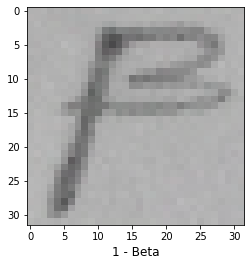

In [807]:
# Let's show one of the Image from our X Array.
index = 4

img = X[index]
label = y[index][0]
class_ = classes[label]

print('Shape of the Image: ', img.shape)

plt.imshow(img)
plt.xlabel('{} - {}'.format(label, class_), size=12)
plt.show()

In [808]:
# Now let's randomize the all the X and y that we have.
X_y = []
for i in range(len(X)):
    inst_arr = []
    inst_X = X[i]
    inst_y = y[i]
    inst_arr.append(inst_X)
    inst_arr.append(inst_y)
    
    X_y.append(inst_arr)

# Randomizing X_y with a Random seed 4.
random.Random(4).shuffle(X_y)

len(X_y)

48

In [809]:
# Now we have a fully ready Feature Label Dataset.
# Now let's do a Train Dev split.
# We have tatal of 48 examples. So with this much less data let's follow the traditional rule of thumb to do a 
# 70-30 split.

cut_up = round(len(X_y)*(70/100))

Train = X_y[0:cut_up]
Dev = X_y[cut_up:]

print(len(Train))
print(len(Dev))

34
14


In [810]:
# Preparing the the Trainging set in a way Tensorflow-Keras Models expect.
X_train = [ele[0] for ele in Train]
X_train = np.array(X_train)
print(X_train.shape)

y_train = [ele[1] for ele in Train]
y_train = np.array(y_train)
print(y_train.shape)

X_dev = [ele[0] for ele in Dev]
X_dev = np.array(X_dev)
print(X_dev.shape)

y_dev = [ele[1] for ele in Dev]
y_dev = np.array(y_dev)
print(y_dev.shape)

(34, 32, 32, 3)
(34, 1)
(14, 32, 32, 3)
(14, 1)


In [811]:
# Actually in practice input shape is flatten. So we are going to flatted the input array.
X_train = X_train.reshape(-1, 32*32*3)
X_train.shape

(34, 3072)

## Building a Neural Network
In this problem we are going to use just a traditional Neural Network just having a bunch of Dense layers.

In [812]:
# Defining the 'Layers' with No. of 'Neurons' and 'Activatioin Functions'.
inputs = keras.Input(shape=(3072))
outputs = layers.Dense(3, activation='softmax')(inputs)

# Building the Model with the above Layers.
model = keras.Model(inputs=inputs, outputs=outputs)

# Verifying the whether the model is as per the way we want or not.
model.summary()

Model: "model_46"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_45 (InputLayer)        [(None, 3072)]            0         
_________________________________________________________________
dense_44 (Dense)             (None, 3)                 9219      
Total params: 9,219
Trainable params: 9,219
Non-trainable params: 0
_________________________________________________________________


In [813]:
# Definging the 'Cost Function', 'Optimizer' and 'Evaluation Metrics' for the Model.
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [814]:
# Training the Model.
model.fit(X_train, y_train, batch_size=len(X_train), epochs=128, verbose=2)

Epoch 1/128
1/1 - 0s - loss: 439.8256 - accuracy: 0.4118
Epoch 2/128
1/1 - 0s - loss: 358.0905 - accuracy: 0.3235
Epoch 3/128
1/1 - 0s - loss: 321.0797 - accuracy: 0.2647
Epoch 4/128
1/1 - 0s - loss: 167.7084 - accuracy: 0.2647
Epoch 5/128
1/1 - 0s - loss: 143.3570 - accuracy: 0.3235
Epoch 6/128
1/1 - 0s - loss: 235.0134 - accuracy: 0.4118
Epoch 7/128
1/1 - 0s - loss: 305.8736 - accuracy: 0.4118
Epoch 8/128
1/1 - 0s - loss: 251.5648 - accuracy: 0.4118
Epoch 9/128
1/1 - 0s - loss: 197.3372 - accuracy: 0.3235
Epoch 10/128
1/1 - 0s - loss: 184.5071 - accuracy: 0.3235
Epoch 11/128
1/1 - 0s - loss: 82.0327 - accuracy: 0.6176
Epoch 12/128
1/1 - 0s - loss: 41.8796 - accuracy: 0.4412
Epoch 13/128
1/1 - 0s - loss: 129.5934 - accuracy: 0.2647
Epoch 14/128
1/1 - 0s - loss: 158.3000 - accuracy: 0.2647
Epoch 15/128
1/1 - 0s - loss: 59.2017 - accuracy: 0.5000
Epoch 16/128
1/1 - 0s - loss: 81.1177 - accuracy: 0.3235
Epoch 17/128
1/1 - 0s - loss: 83.6845 - accuracy: 0.5588
Epoch 18/128
1/1 - 0s - loss

In [815]:
# Before Evaluating let's make the X_dev flattern.
X_dev = X_dev.reshape(-1, 32*32*3)

# Evaluating the Model
print(model.evaluate(X_dev, y_dev, batch_size=len(X_dev), verbose=2))

1/1 - 0s - loss: 0.0000e+00 - accuracy: 1.0000
[0.0, 1.0]


In [816]:
# Saving the Model.
model.save('models/model_1/')

INFO:tensorflow:Assets written to: models/model_1/assets


## Model Building Completed
From the above Evaluation it seems that our Model is getting an Accuracy of 100%.

This is awesome. Let's Test our Model to know how it performs for purely unseed data.

## Model Testing

In [817]:
# Importing the Model.
model_test = tf.keras.models.load_model('models/model_1/')

model.summary()

Model: "model_46"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_45 (InputLayer)        [(None, 3072)]            0         
_________________________________________________________________
dense_44 (Dense)             (None, 3)                 9219      
Total params: 9,219
Trainable params: 9,219
Non-trainable params: 0
_________________________________________________________________


In [818]:
# Importing the Test Data and Preprosess it to the format our model is expecting.

# Lists all the file names from the Source folder
base_path = 'data/test/testing_data_resized/'

files = os.listdir(base_path)
files = [file for file in files if file[-1] != '~']

print(len(files))

# Getting all the images in RGB formats and storing them all in a container array
classes = ['Alpha', 'Beta', 'Gamma']

X_test = []
y_test = []

for file in files:
    # Creating the File path (Image Path).
    file_path = base_path + file
    # Opening the Image using OpenCV
    inst_img = cv2.imread(file_path)
    # Converting the img to a Numpy Array
    inst_img_arr = np.array(inst_img)
    # Adding the Image Array to the Container Array. 
    X_test.append(inst_img_arr)
    
    # The other thing is to use grab the label from the Image name.
    inst_label = int(file[0])
    # Append the label to the 'y' Array.
    y_test.append(inst_label)
    
# Converting both X and y to Numpy Arrays for Efficient Computaion.
X_test = np.array(X_test)
y_test = np.array(y_test).reshape(12, -1)

print('Shape of X_test: ', X_test.shape)
print('Shape of y_test: ', y_test.shape)

12
Shape of X_test:  (12, 32, 32, 3)
Shape of y_test:  (12, 1)


Shape of the Image:  (32, 32, 3)


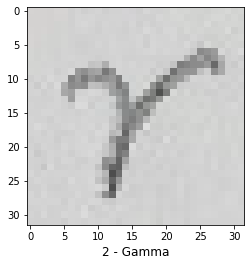

Shape of the Image:  (32, 32, 3)


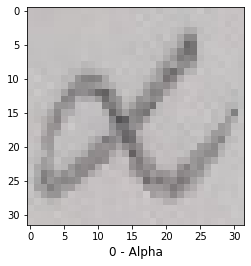

In [819]:
# Visualizing our Test Data
def plot(index):
    index = index

    img = X_test[index]
    label = y_test[index][0]
    class_ = classes[label]

    print('Shape of the Image: ', img.shape)

    plt.imshow(img)
    plt.xlabel('{} - {}'.format(label, class_), size=12)
    plt.show()
    
for i in range(2):
    plot(i)

In [820]:
# Reshaping our Data Arrays.
# Reshapeing the X and y
X_test = X_test.reshape(-1, 32*32*3)

print(X_test.shape)

(12, 3072)


In [821]:
# Evaluating our Model on Test Data.
print(model_test.evaluate(X_test, y_test, batch_size=len(X_test), verbose=2))

1/1 - 0s - loss: 4.2233 - accuracy: 0.8333
[4.223320007324219, 0.8333333134651184]
